# Nonlinear timing with MetaPulsar

This notebook shows the sampler-facing **nonlinear timing** (NLT) workflow end to end:

1. build a `MetaPulsar` host from par/tim files,
2. configure a `NonLinearTimingModel` and **bind** it to the host,
3. assemble a Discovery likelihood and sample it with NumPyro NUTS,
4. write the **NLT artifact sidecar** and decode the chain back to physical
   timing parameters — without any live model objects,
5. repeat the analysis for a **multi-PTA binary combination** with custom
   priors, sampled through **both** frontends: Discovery/NUTS and
   Enterprise/PTMCMC.

Instead of holding every timing parameter fixed at its par-file value (or
linearizing around it), the nonlinear timing model *numerically samples* a
chosen subset of timing parameters inside the likelihood, while the remaining
linear nuisance parameters are analytically marginalized.

**Requirements**: `jug-timing` (JAX timing engine), `discovery`, `numpyro`,
`enterprise-pulsar`, and `PTMCMCSampler` — all available in the MetaPulsar
devcontainer. The datasets are simulated with PINT, so no external data
releases are needed.

In [1]:
# JAX must see this before it is first imported.
import os

os.environ.setdefault("JAX_ENABLE_X64", "1")

'1'

In [2]:
import tempfile
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np

from metapulsar import create_metapulsar
from metapulsar.sandbox_tempo2 import configure_logging
from metapulsar.timing import NLTChainBundle, NonLinearTimingModel, sampling
from metapulsar.timing.artifacts import save_discovery_checkpoint

configure_logging(level="WARNING")
workdir = Path(tempfile.mkdtemp(prefix="nlt_demo_"))

## 1. Simulate a demo dataset

We simulate ~150 TOAs from PINT's bundled `NGC6440E` example par file. Because
the TOAs are drawn from the model itself (plus white noise), we know the true
parameter values exactly — useful for checking the posterior at the end.

In [3]:
import pint.config
from pint.models import get_model
from pint.simulation import make_fake_toas_uniform

np.random.seed(42)

model = get_model(pint.config.examplefile("NGC6440E.par"))
toas = make_fake_toas_uniform(
    startMJD=53400,
    endMJD=56000,
    ntoas=150,
    model=model,
    obs="gbt",
    error=1.0,  # us
    add_noise=True,
)

par_path = workdir / "demo.par"
tim_path = workdir / "demo.tim"
par_path.write_text(model.as_parfile())
toas.write_TOA_file(str(tim_path), format="tempo2")

## 2. Build the MetaPulsar host

`create_metapulsar` takes a `file_data` mapping of PTA name → par/tim entries.
Here we use a single "PTA"; a real multi-PTA combination simply adds more
entries (EPTA, PPTA, NANOGrav, …) to the same dictionary.

In [4]:
file_data = {
    "demo": [
        {"par": str(par_path), "tim": str(tim_path), "timing_package": "pint"}
    ]
}
mp = create_metapulsar(file_data, use_pulse_numbers="no")

print(f"pulsar:  {mp.name}")
print(f"TOAs:    {len(mp.toas)}")
print(f"fitpars: {list(mp.fitpars)}")

pulsar:  J1748-2021
TOAs:    150
fitpars: ['RAJ', 'DECJ', 'F0', 'F1', 'DM', 'DM1', 'DM2', 'Offset_demo']


## 3. Configure the nonlinear timing model

`sample=` names the timing parameters to sample numerically — base names match
PTA-suffixed fitpars automatically on composite hosts — and everything else is
analytically marginalized. `bind()` resolves the configuration against the
host and returns a `TimingBinding`, which owns all pulsar-bound queries.

The default `transform="whitening"` samples in decorrelated coordinates; the
default `engines="jug"` uses the JAX timing engine, which NUTS needs for
autodiff. For binary pulsars you can pass priors right here, e.g.
`priors={"TASC": priors.delta_uniform(-0.5, 0.5, scale="PB")}`.

In [5]:
ntm = NonLinearTimingModel(engines="jug", sample=["F0", "F1"], name="timing")
binding = ntm.bind(mp)

print(f"sampled:      {binding.sampled}")
print(f"marginalized: {binding.marginalized}")

[!] Unrecognized par file parameters (ignored by JUG): DMDATA, NE_SW1


[FITTER] noise_config was None, auto-detecting from par file
sampled:      ('F0', 'F1')
marginalized: ('RAJ', 'DECJ', 'DM', 'DM1', 'DM2', 'Offset_demo')


## 4. Discovery likelihood and NUTS sampling

`binding.discovery_signals()` returns Discovery-native signal objects (an
improper GP for the marginalized block plus a JAX nonlinear delay) that splat
directly into `PulsarLikelihood` — no changes to Discovery required.

`sampling.numpyro.model` builds the standard NumPyro model (timing parameters
enter through one joint sample site with the physical prior attached), and
`sampling.numpyro.nuts` returns a configured `MCMC` with float64 enforced and
the chain initialized at the par-file reference.

In [6]:
import discovery as ds

noisedict = {f"{mp.name}_efac": 1.0, f"{mp.name}_log10_t2equad": -8.0}

likelihood = ds.PulsarLikelihood(
    [
        mp.residuals,
        ds.makenoise_measurement_simple(mp, noisedict),
        *binding.discovery_signals(),
    ]
)

nlt_model = sampling.numpyro.model(likelihood, binding, fixed=noisedict)
mcmc = sampling.numpyro.nuts(nlt_model, binding, num_warmup=500, num_samples=1000)
mcmc.run(jax.random.PRNGKey(0))

x = sampling.numpyro.timing_draws(mcmc.get_samples(), binding)
print(f"latent draws: {x.shape}")

  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:00<08:18,  3.01it/s, 3 steps of size 1.59e+01. acc. prob=0.90]

warmup:  13%|█▎        | 192/1500 [00:00<00:02, 575.36it/s, 7 steps of size 8.19e-01. acc. prob=0.63]

warmup:  26%|██▋       | 397/1500 [00:00<00:01, 1017.00it/s, 3 steps of size 1.06e+00. acc. prob=0.64]

sample:  41%|████      | 613/1500 [00:00<00:00, 1357.46it/s, 3 steps of size 9.45e-01. acc. prob=0.85]

sample:  56%|█████▌    | 835/1500 [00:00<00:00, 1613.92it/s, 7 steps of size 9.45e-01. acc. prob=0.82]

sample:  71%|███████   | 1061/1500 [00:00<00:00, 1805.76it/s, 3 steps of size 9.45e-01. acc. prob=0.82]

sample:  86%|████████▌ | 1284/1500 [00:00<00:00, 1932.54it/s, 5 steps of size 9.45e-01. acc. prob=0.81]

sample: 100%|██████████| 1500/1500 [00:01<00:00, 1455.89it/s, 7 steps of size 9.45e-01. acc. prob=0.82]

latent draws: (1000, 2)


## 5. Artifacts: persist and decode without a live model

`binding.write(...)` snapshots everything needed to interpret the chain — the
serialized parameter space, units, fingerprints — into a small sidecar
(`nlt_sidecar.json` + `nlt_parameter_space.{json,npz}`). Later (or on another
machine), `NLTChainBundle` decodes the raw chain into physical timing
parameters from those files alone: no MetaPulsar host, PTA data, or timing
engine required.

In [7]:
outdir = workdir / "run"
artifact = binding.write(
    outdir,
    frontend="discovery",
    sampler="numpyro-nuts",
    latent={"kind": "npz", "path": "discovery_x.npz", "key_name": "x"},
)
save_discovery_checkpoint(outdir, x, artifact, final=True)

bundle = NLTChainBundle.load(outdir)
post = bundle.posterior(units="display")
truths = bundle.truths()

for name in binding.sampled:
    lo, hi = np.percentile(post[name], [16, 84])
    print(f"{name}: truth = {truths[name]:.12g}   68% interval = [{lo:.12g}, {hi:.12g}]")

F0: truth = 61.485476554   68% interval = [61.4854765508, 61.4854765539]
F1: truth = -1.181e-15   68% interval = [-1.18949431703e-15, -1.15268844951e-15]


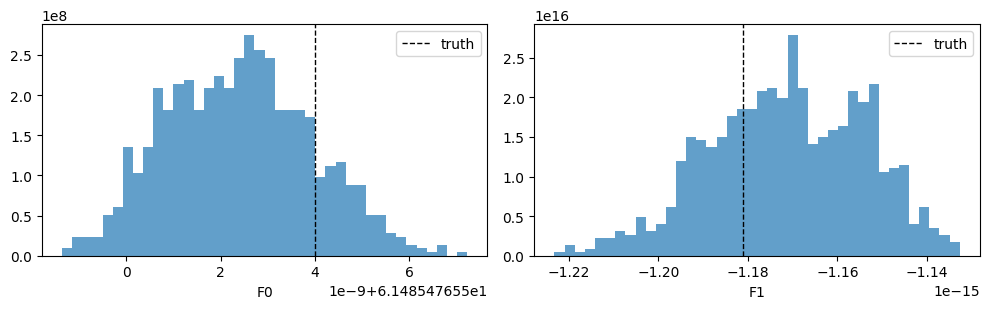

In [8]:
fig, axes = plt.subplots(1, len(binding.sampled), figsize=(10, 3.2))
for ax, name in zip(np.atleast_1d(axes), binding.sampled):
    ax.hist(post[name], bins=40, density=True, alpha=0.7)
    ax.axvline(truths[name], color="k", ls="--", lw=1, label="truth")
    ax.set_xlabel(name)
    ax.legend()
fig.tight_layout()

## 6. Multi-PTA combination with a binary pulsar

The same API scales to the real use case: several PTAs observing one (binary)
pulsar. We simulate two overlapping datasets from an ELL1 binary par file and
combine them into a single host — each PTA contributes its own dataset (and
per-PTA phase offset), while the timing parameters are made consistent across
PTAs.

Two new pieces of the model configuration appear here:

- `sample=` with **base names**: `"PB"` selects the orbital period however it
  is spelled on the combined host (including PTA-suffixed variants on
  composite hosts).
- `priors=` with the spec helpers from `metapulsar.timing.priors`:
  `delta_uniform(-0.5, 0.5, scale="PB")` puts a uniform prior on the TASC
  *offset* of ± half an orbital period — the bounds are multiplied by the
  bound PB reference at bind time (suffix-consistently on composite hosts).

In [9]:
BINARY_PAR = """\
PSRJ           J1234+4500
RAJ            12:34:00.0        1
DECJ           45:00:00.0        1
PMRA           0.0
PMDEC          0.0
F0             200.0             1
F1             -1.0e-15          1
PEPOCH         55000
POSEPOCH       55000
DMEPOCH        55000
DM             15.0              1
BINARY         ELL1
PB             12.3              1
A1             8.5               1
TASC           55000.1           1
EPS1           1.0e-6            1
EPS2           -2.0e-6           1
EPHEM          DE440
CLK            TT(BIPM2019)
UNITS          TDB
"""

binary_par = workdir / "binary.par"
binary_par.write_text(BINARY_PAR)
binary_model = get_model(str(binary_par))

np.random.seed(1)
spans = {"pta_a": (53000, 56500, "gbt"), "pta_b": (55000, 58000, "parkes")}
file_data2 = {}
for pta, (start, end, obs) in spans.items():
    fake = make_fake_toas_uniform(
        startMJD=start, endMJD=end, ntoas=120, model=binary_model, obs=obs,
        error=1.0, add_noise=True,
    )
    tim = workdir / f"{pta}.tim"
    fake.write_TOA_file(str(tim), format="tempo2")
    file_data2[pta] = [
        {"par": str(binary_par), "tim": str(tim), "timing_package": "pint"}
    ]

mp2 = create_metapulsar(file_data2, use_pulse_numbers="no")
print(f"pulsar:  {mp2.name}   TOAs: {len(mp2.toas)}  (2 PTAs)")
print(f"fitpars: {list(mp2.fitpars)}")

pulsar:  J1233+4500   TOAs: 240  (2 PTAs)
fitpars: ['RAJ', 'DECJ', 'F0', 'F1', 'DM', 'DM1', 'DM2', 'PB', 'A1', 'TASC', 'EPS1', 'EPS2', 'Offset_pta_a', 'Offset_pta_b']


In [10]:
from metapulsar.timing import priors as nlt_priors

ntm2 = NonLinearTimingModel(
    engines="jug",
    sample=["PB", "TASC", "A1"],
    priors={"TASC": nlt_priors.delta_uniform(-0.5, 0.5, scale="PB")},
    name="timing",
)
binding2 = ntm2.bind(mp2)

print(f"sampled:       {binding2.sampled}")
print(f"marginalized:  {binding2.marginalized}")
print(f"prior sources: {binding2.priors.sources}")

[FITTER] noise_config was None, auto-detecting from par file


[FITTER] noise_config was None, auto-detecting from par file
sampled:       ('PB', 'A1', 'TASC')
marginalized:  ('RAJ', 'DECJ', 'F0', 'F1', 'DM', 'DM1', 'DM2', 'EPS1', 'EPS2', 'Offset_pta_a', 'Offset_pta_b')
prior sources: {'PB': 'cheat_wls', 'A1': 'cheat_wls', 'TASC': 'override'}


The Discovery + NUTS pattern is identical to the single-PTA case — the
composite backend evaluates each PTA's rows with its own engine session and
assembles them in canonical TOA order behind the scenes.

In [11]:
noisedict2 = {f"{mp2.name}_efac": 1.0, f"{mp2.name}_log10_t2equad": -8.0}

likelihood2 = ds.PulsarLikelihood(
    [
        mp2.residuals,
        ds.makenoise_measurement_simple(mp2, noisedict2),
        *binding2.discovery_signals(),
    ]
)

nlt_model2 = sampling.numpyro.model(likelihood2, binding2, fixed=noisedict2)
mcmc2 = sampling.numpyro.nuts(nlt_model2, binding2, num_warmup=500, num_samples=1000)
mcmc2.run(jax.random.PRNGKey(1))
x2 = sampling.numpyro.timing_draws(mcmc2.get_samples(), binding2)

ds_dir = workdir / "run_discovery_binary"
artifact2 = binding2.write(
    ds_dir,
    frontend="discovery",
    sampler="numpyro-nuts",
    latent={"kind": "npz", "path": "discovery_x.npz", "key_name": "x"},
)
save_discovery_checkpoint(ds_dir, x2, artifact2, final=True)
post_ds = NLTChainBundle.load(ds_dir).posterior(units="display")

  0%|          | 0/1500 [00:00<?, ?it/s]

warmup:   0%|          | 1/1500 [00:00<14:58,  1.67it/s, 3 steps of size 1.18e+01. acc. prob=0.74]

warmup:   3%|▎         | 52/1500 [00:00<00:14, 99.20it/s, 7 steps of size 1.28e+00. acc. prob=0.63]

warmup:   8%|▊         | 116/1500 [00:00<00:06, 214.11it/s, 15 steps of size 7.71e-01. acc. prob=0.63]

warmup:  11%|█         | 167/1500 [00:00<00:04, 280.45it/s, 15 steps of size 9.41e-01. acc. prob=0.63]

...

sample:  87%|████████▋ | 1300/1500 [00:02<00:00, 612.83it/s, 11 steps of size 9.09e-01. acc. prob=0.86]

sample:  91%|█████████ | 1364/1500 [00:02<00:00, 619.18it/s, 3 steps of size 9.09e-01. acc. prob=0.86] 

sample:  95%|█████████▌| 1427/1500 [00:02<00:00, 618.26it/s, 15 steps of size 9.09e-01. acc. prob=0.85]

sample:  99%|█████████▉| 1489/1500 [00:03<00:00, 596.47it/s, 3 steps of size 9.09e-01. acc. prob=0.86] 

sample: 100%|██████████| 1500/1500 [00:03<00:00, 481.40it/s, 3 steps of size 9.09e-01. acc. prob=0.86]

## 7. The same binding with Enterprise + PTMCMC

`ntm.enterprise_signal()` returns an Enterprise-native signal class that
combines with any other Enterprise signals and binds per pulsar, exactly like
stock components. The `sampling.ptmcmc` module owns the sampler-vector ↔
likelihood-parameter mapping for both timing coordinate layouts (the
whitening joint site used here, or standardized scalar columns), so no
hand-written `vec_to_params` is needed.

`sampling.ptmcmc.chain_layout(...)` records which chain columns hold the
timing coordinates in the artifact sidecar — `NLTChainBundle` then decodes
the raw PTMCMC `chain_1.txt` directly, with burn-in and thinning applied
consistently to the latent and physical views.

In [12]:
from enterprise.signals import parameter, signal_base, white_signals

ef = white_signals.MeasurementNoise(efac=parameter.Constant(1.0))
ent_model = ef + ntm2.enterprise_signal()
pta = signal_base.PTA([ent_model(mp2)])
print(f"pta params: {pta.param_names}")

ent_dir = workdir / "run_enterprise_binary"
pts = sampling.ptmcmc.sampler(pta, binding2, ent_dir, verbose=False)
pts.sample(
    p0=sampling.ptmcmc.initial_point(binding2),
    Niter=20000,
    burn=2000,
    thin=1,
)

layout = sampling.ptmcmc.chain_layout(binding2, pta.param_names)
binding2.write(ent_dir, frontend="enterprise", sampler="ptmcmc", chain_layout=layout)

post_ent = NLTChainBundle.load(ent_dir).posterior(burn=0.25, units="display")
truths2 = NLTChainBundle.load(ent_dir).truths()

for name in binding2.sampled:
    lo_d, hi_d = np.percentile(post_ds[name] - truths2[name], [16, 84])
    lo_e, hi_e = np.percentile(post_ent[name] - truths2[name], [16, 84])
    print(f"{name} (68% interval, offset from truth):")
    print(f"  discovery  = [{lo_d:+.3e}, {hi_d:+.3e}]")
    print(f"  enterprise = [{lo_e:+.3e}, {hi_e:+.3e}]")

pta params: ['J1233+4500_timing_x_0', 'J1233+4500_timing_x_1', 'J1233+4500_timing_x_2']


PB (68% interval, offset from truth):
  discovery  = [-2.549e-10, +1.455e-10]
  enterprise = [-2.724e-10, +1.478e-10]
A1 (68% interval, offset from truth):
  discovery  = [-1.313e-07, +4.416e-08]
  enterprise = [-1.277e-07, +5.511e-08]
TASC (68% interval, offset from truth):
  discovery  = [-2.004e-08, +2.442e-08]
  enterprise = [-2.078e-08, +2.468e-08]


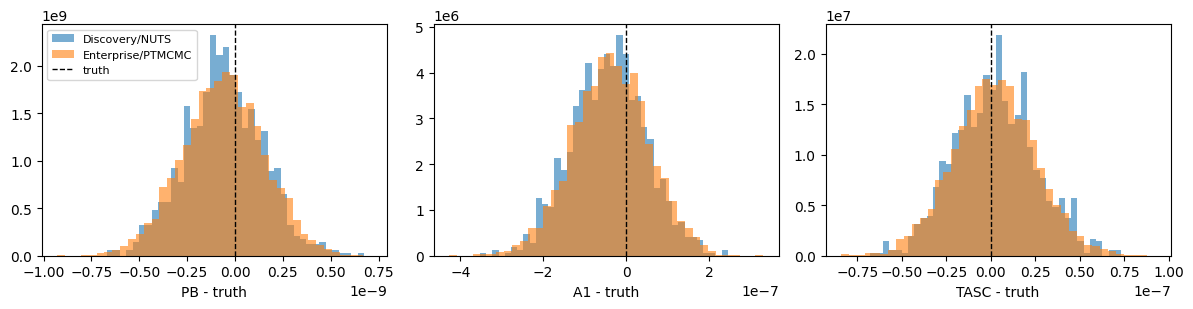

In [13]:
fig, axes = plt.subplots(1, len(binding2.sampled), figsize=(12, 3.2))
for ax, name in zip(np.atleast_1d(axes), binding2.sampled):
    ax.hist(
        post_ds[name] - truths2[name],
        bins=40, density=True, alpha=0.6, label="Discovery/NUTS",
    )
    ax.hist(
        post_ent[name] - truths2[name],
        bins=40, density=True, alpha=0.6, label="Enterprise/PTMCMC",
    )
    ax.axvline(0.0, color="k", ls="--", lw=1, label="truth")
    ax.set_xlabel(f"{name} - truth")
axes[0].legend(fontsize=8)
fig.tight_layout()

## Beyond this notebook

- **Heterogeneous engines** — on hosts mixing tempo2-native and PINT-native
  PTAs, engines are selected per native compatibility:
  `engines={"tempo2": "jug", "pint": "jug"}` (all-JAX, NUTS-capable) or
  `engines={"tempo2": "libstempo", "pint": "pint"}` (native engines; use the
  Enterprise/PTMCMC path, since NUTS needs JAX autodiff).
- **tempo2-native mode** — pass `tempo2_native=...` and
  `design_matrix_method="autodiff"` for JUG's tempo2-compatible nonlinear
  path on real tempo2-era data (see `jug.timing` for the graph modes).
- **Artifacts as the interchange contract** — everything decoded above used
  only the sidecar files plus raw sampler output; ship a run directory
  anywhere and `NLTChainBundle` reproduces the physical posteriors without
  MetaPulsar, PTA data, or a timing engine installed.